In [2]:
R.<x> = PolynomialRing(QQ)
from sage.rings.polynomial.cyclotomic import cyclotomic_coeffs
S = QQ['x']
import numpy as np
import matplotlib.pyplot as plt

def count_poly(q,n):
    s = 0 
    for d in range(1,n+1):
        if (n %d )==0:
            s+= moebius(n//d)*q**d
    return s//n

def necklace_coefficient(d,n):
    if d == 0:
        return 0 
    elif n % d !=0:
        return 0 
    else:
        return moebius(n//d)
def raw_necklace(n):
    v=[necklace_coefficient(a+1,n) for a in range(0,n+1)]
    F_D=R(v)
    return F_D*x

def necklace_function(n):
    s = 0 
    for d in range(1,n+1):
        if n%d == 0:
            s += moebius(d)*x**(n//d)
    return s/n
    


# We test the above code with some small values of $n$

In [119]:
F = necklace_function(4)
F

1/4*x^4 - 1/4*x^2

In [120]:
F.derivative()

x^3 - 1/2*x

The graph of $M_4(x)$ on the interval $[1, 5]$

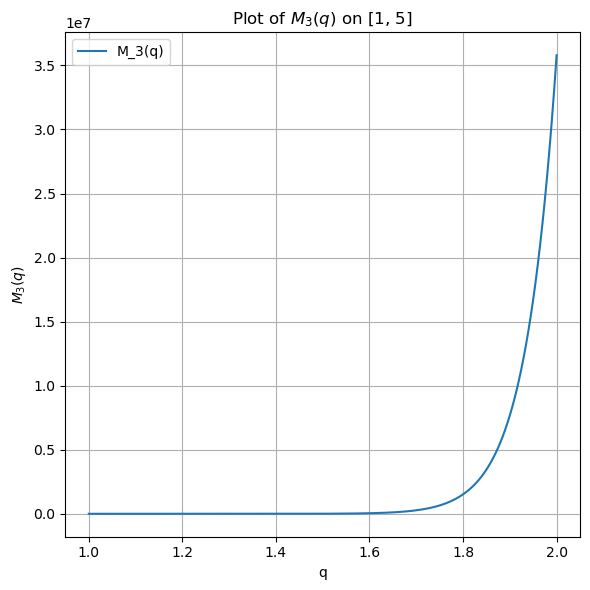

In [12]:
q = np.linspace(1, 2, 200)
y = np.array([F(t) for t in q])
# Plot
plt.figure(figsize=(6, 6))
plt.plot(q, y, label='M_3(q)')
plt.xlabel('q')
plt.ylabel('$M_3(q)$')
plt.title('Plot of $M_3(q)$ on [1, 5]')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


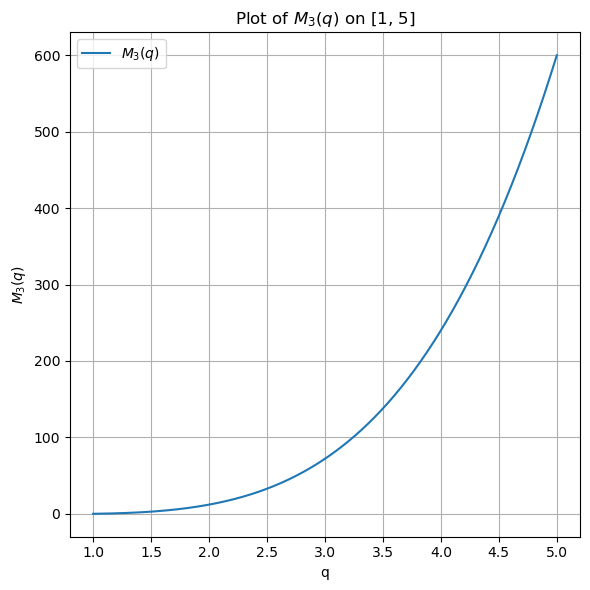

In [16]:
q = np.linspace(1, 5, 500)
F = raw_necklace(4)
y = [F(t) for t in q]
# Plot
plt.figure(figsize=(6, 6))
plt.plot(q, y, label=f'$M_{{3}}(q)$')
plt.xlabel('q')
plt.ylabel('$M_3(q)$')
plt.title('Plot of $M_3(q)$ on [1, 5]')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [17]:
n = 21
F= necklace_function(n)
F

1/21*x^21 - 1/21*x^7 - 1/21*x^3 + 1/21*x

# A family of normalized necklace-functions $\frac{M_n(x)}{x^n}$

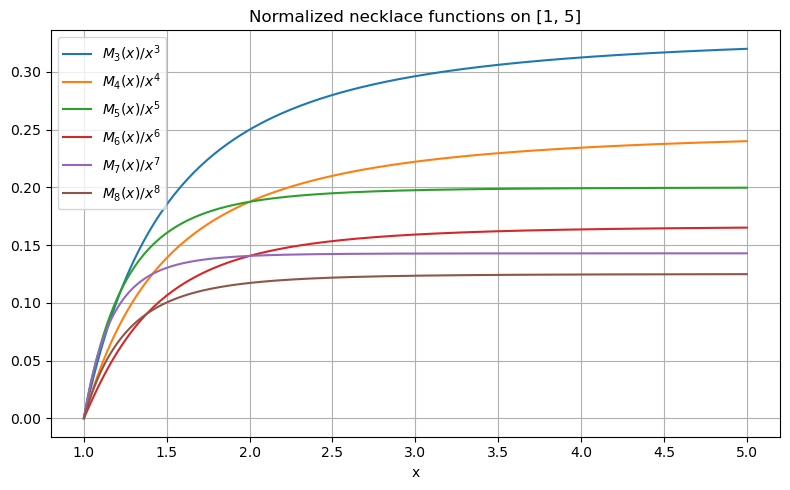

In [165]:
q = np.linspace(1, 5, 200)
plt.figure(figsize=(8, 5))
for n in range(3,9):
    F = necklace_function(n)
    y =[F(t)/t**n for t in q]
    plt.plot(q, y, label=f'$M_{n}(x)/x^{n}$')
plt.xlabel('x')
plt.title('Normalized necklace functions on [1, 5]')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('noralized_M_functions.pdf', format='pdf', bbox_inches='tight', dpi=200)
plt.show()


# A family of normalized derivative $\frac{M'_n(x)}{x^n}$ 

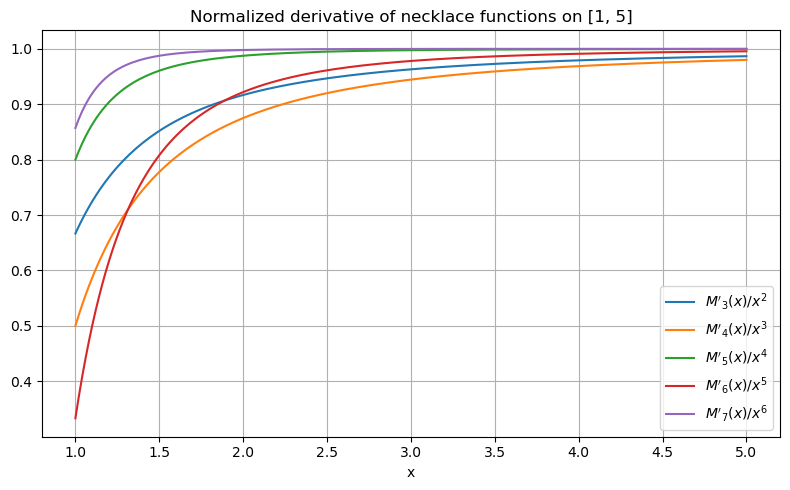

In [166]:
q = np.linspace(1, 5, 200)
plt.figure(figsize=(8, 5))
for n in range(3,8):
    H = necklace_function(n)
    F = x*H.derivative()
    y =[F(t)/t**n for t in q]
    plt.plot(q, y, label=f"$M'_{n}(x)/x^{n-1}$")
plt.xlabel('x')
plt.title('Normalized derivative of necklace functions on [1, 5]')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('noralized_derivative_P_functions.pdf', format='pdf', bbox_inches='tight', dpi=200)
plt.show()

# A family of the normalized derivative of necklace functions $\frac{M'_n(x)}{x^n}$

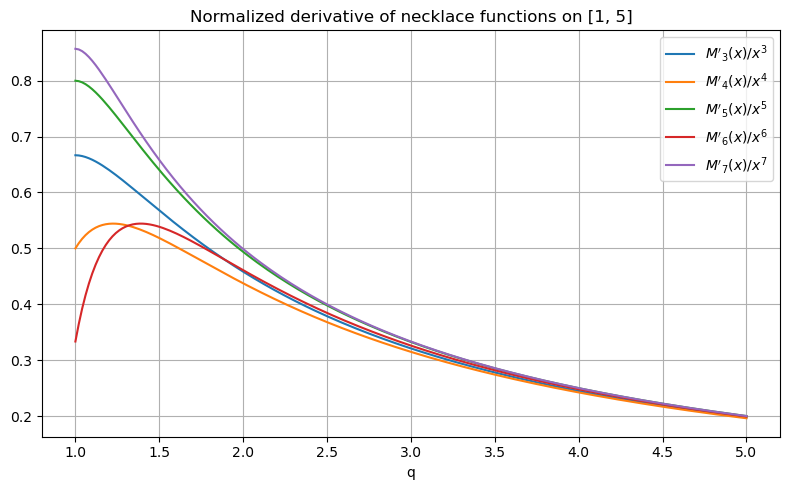

In [163]:
q = np.linspace(1, 5, 200)
plt.figure(figsize=(8, 5))
for n in range(3,8):
    H = necklace_function(n)
    F = x*H.derivative()
    y =[F(t)/t**(n+1) for t in q]
    plt.plot(q, y, label=f"$M'_{n}(x)/x^{n}$")
plt.xlabel('q')
plt.title('Normalized derivative of necklace functions on [1, 5]')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('wrong_noralized_derivative_P_functions.pdf', format='pdf', bbox_inches='tight', dpi=200)
plt.show()